In [1]:
import sklearn
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import kagglehub
path = kagglehub.dataset_download("brendan45774/test-file")
import os

100%|██████████| 11.2k/11.2k [00:00<00:00, 15.5MB/s]

Extracting files...


In [3]:
file_path = os.path.join(path , 'tested.csv')

## Classification Problem
Target: Survived(0= Dead , 1 = Survived)
#### Started at 11:30 AM

In [233]:
df = pd.read_csv(file_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [234]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [235]:
df.shape

(418, 12)

### Removing Useless Columns
(Although you said, family members , passenger class can be important features, i dont see how it helps in classifying who died who survived.)
## 1 Passenger ID - Useless



In [236]:
df = df.drop(['PassengerId'], axis=1)

### Checking relationship of ticket with survived

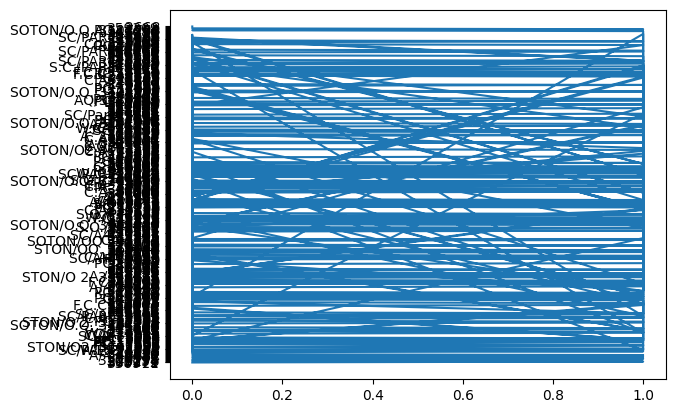

In [237]:
plt.plot(df['Survived'], df['Ticket'])

### Graph shows that ticket is absolutely useless.
### As Ticket is alpha numeric (not numeric) we can not check its variance, co-relation with survived feature.

In [238]:
df['Ticket'].nunique()

363

#### 418 total rows, 363 unique values.
#### Verdict: Encoding ticket will make dataset huge. , removing Alpha part of ticket makes no sense.
### Final Decision: Drop Ticket (hehe)

In [239]:
df = df.drop(['Ticket'], axis=1)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,NaN,Q
1,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,NaN,S
2,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,9.6875,NaN,Q
3,0,3,"Wirz, Mr. Albert",male,27.0,0,0,8.6625,NaN,S
4,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,NaN,S


### Handling sibSp , Parch columns.
#### Lets combine them to create a FamilyMembers column

In [240]:
df['FamilyNo'] = df['Parch'] + df['SibSp']
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,FamilyNo
0,0,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,NaN,Q,0
1,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,NaN,S,1
2,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,9.6875,NaN,Q,0
3,0,3,"Wirz, Mr. Albert",male,27.0,0,0,8.6625,NaN,S,0
4,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,NaN,S,2


In [241]:
print(df['SibSp'].max())
print(df['Parch'].max())
print(df['FamilyNo'].max())

8
9
10


### Lets keep all of them for now, we will test removing them one by one and check performance.

#### I check the syntax on web :( , but still i learned somethiing new!

#### AgeGroups:
AM - Adult Male,
AF - Adult Female,
UM - Underage Male,
UF - Unmarried Female

In [242]:
condition = [df['Name'].str.contains('Mr.') ,  df['Name'].str.contains('Mrs.'), df['Name'].str.contains('Master'), df['Name'].str.contains('Miss')]
choice = ['AM' , 'AF' , 'UM' , 'UF']
df['AgeGroup'] = np.select(condition , choice, default='AM')

In [243]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,FamilyNo,AgeGroup
0,0,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,NaN,Q,0,AM
1,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,NaN,S,1,AM
2,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,9.6875,NaN,Q,0,AM
3,0,3,"Wirz, Mr. Albert",male,27.0,0,0,8.6625,NaN,S,0,AM
4,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,NaN,S,2,AM


#### It's time to say bye bye to Name column as we have extracted the gendre with age groups, and theres no need to encode names.

In [244]:
df = df.drop(['Name'], axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,FamilyNo,AgeGroup
0,0,3,male,34.5,0,0,7.8292,NaN,Q,0,AM
1,1,3,female,47.0,1,0,7.0000,NaN,S,1,AM
2,0,2,male,62.0,0,0,9.6875,NaN,Q,0,AM
3,0,3,male,27.0,0,0,8.6625,NaN,S,0,AM
4,1,3,female,22.0,1,1,12.2875,NaN,S,2,AM


### Handling Cabin column ,  lots of missing values, seems useless to me.

In [245]:
df['Cabin'].nunique()

76

In [246]:
df['Cabin'].isna().sum()

np.int64(327)

327 Missing values out of 418 total, Definitly needs to go to Trash!

In [249]:
df = df.drop(['Cabin' , 'Fare' , 'Pclass' , 'SibSp'	,'Parch'], axis=1)

In [250]:
df.head()

,Survived,Sex,Age,Embarked,FamilyNo,AgeGroup
0,0,male,34.5,Q,0,AM
1,1,female,47.0,S,1,AM
2,0,male,62.0,Q,0,AM
3,0,male,27.0,S,0,AM
4,1,female,22.0,S,2,AM


### Although Embarked , PClass ,  Fare Do not look much helpful, we will keep them then remove one by one and check performance.

In [251]:
df.var(numeric_only=True)

,0
Survived,0.231960
Age,201.106695
FamilyNo,2.307580


In [252]:
df['Survived'].value_counts(normalize=True)

,proportion
Survived,
0,0.636364
1,0.363636


### We can See our dataset is Biased towards Class 0 of survival.
Searching on web how to handle biased datasets.

In [253]:
majority = df[df['Survived'] == 0]
minority = df[df['Survived'] ==1]

maj_reduced = majority.sample(len(minority))


seperated survived column into two.
took a subset from majority to match the lenght of minority

In [254]:
df_balanced = pd.concat([maj_reduced , minority])

In [255]:
df_balanced.shape

(304, 6)

In [256]:
df_balanced['Survived'].value_counts()

,count
Survived,
0,152
1,152


#### We lost nearly 100 rows, but got balanced data.

In [257]:
df_balanced.head()

,Survived,Sex,Age,Embarked,FamilyNo,AgeGroup
61,0,male,32.0,S,0,AM
337,0,male,39.0,C,2,AM
28,0,male,41.0,S,0,AM
142,0,male,61.0,C,4,AM
259,0,male,21.0,S,0,AM


Handling Missing Data
In : Age , Fare
Filling Both of them with Mean

In [258]:
df_balanced.isna().sum()

,0
Survived,0
Sex,0
Age,57
Embarked,0
FamilyNo,0
AgeGroup,0


In [261]:
df_balanced['Age'] = df_balanced['Age'].fillna(df_balanced['Age'].mean())


Seperating input and target

In [262]:
x = df_balanced.drop(['Survived'], axis=1)
y = df_balanced['Survived']


In [263]:
x.shape

(304, 5)

In [264]:
y.shape

(304,)

### Spliting data
I went to preprocess directly but then i remembered, we should split data first or there will be data leakage problem.

In [265]:
from sklearn.model_selection import train_test_split

In [266]:
x_train , x_test , y_train , y_test = train_test_split(x , y , random_state=40)

#### Got a doubt: We should split x_train , y_train further into validation set or first apply preprocess?
#### Myguess: First preprocess then split further.
#### Searched on google: Google says otherwise. My whole doubt was on this point that - WHat will be the difference between test data and validatation data if we are not even applying preprocess on it.

### Spliting into validation

In [267]:
x_train , x_val , y_train , y_val = train_test_split(x_train , y_train , random_state=40, train_size=0.75)

In [268]:
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)

(171, 5)
(171,)
(57, 5)
(57,)


### Preprocessing


In [269]:
x_cat = x.select_dtypes(include=(object)).columns
x_num = x.select_dtypes(include='number').columns

In [270]:
x_cat

Index(['Sex', 'Embarked', 'AgeGroup'], dtype='object')

In [271]:
x_num

Index(['Age', 'FamilyNo'], dtype='object')

In [272]:
from sklearn.preprocessing import  StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer

In [273]:
scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown='ignore')

In [274]:
process = ColumnTransformer(
    [
        ('cat', encoder, x_cat),
        ('scale', scaler, x_num)
    ]
)

In [275]:
x_train = process.fit_transform(x_train)

In [276]:
y_train = np.array(y_train)

In [277]:
x_val = process.transform(x_val)
x_test = process.transform(x_test)

In [278]:
x_train.shape

(171, 10)

In [279]:
x_val.shape

(57, 10)

In [280]:
x_test.shape

(76, 10)

## Converting to Tensors

In [281]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
x_val_tensor = torch.tensor(x_val, dtype=torch.float32)


In [282]:
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

In [292]:
x_train_tensor.shape

torch.Size([171, 10])

In [293]:
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).unsqueeze(1)

In [294]:
y_train_tensor.shape

torch.Size([171, 1])

In [295]:
print(torch.isnan(x_train_tensor).any())
print(torch.isinf(x_train_tensor).any())

print(torch.isnan(y_train_tensor).any())
print(torch.isinf(y_train_tensor).any())

tensor(False)
tensor(False)
tensor(False)
tensor(False)


## Let's start with Neural Network

In [296]:
import torch.nn as nn
from torch.optim import Adam
from sklearn.metrics import accuracy_score , classification_report

we have 14 initial features (honestly i feel wierd that how does 10 features total out of which 3 needed encoding only turned out to be 14 features...)

in_features = 14
lets expand them to 32 (i was hoping for lower but as we go by the series : 4 , 16 , 32 and 16 is too close)
then back to 1

In [301]:
class Model(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(10, 32),
        nn.ReLU(),
        nn.Linear(32, 4),
        nn.ReLU(),
        nn.Linear(4, 1)
    )

  def forward(self, x):
    return self.network(x)

In [302]:
model = Model()
optimizer = Adam(model.parameters(), lr=0.01)
creterion = nn.BCEWithLogitsLoss()

## Training

In [303]:
train_loss = []
val_loss = []

for epoch in range(261):
  model.train() # training phase
  prediction = model(x_train_tensor)
  loss = creterion(prediction , y_train_tensor)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  train_loss.append(loss.item())

  # --------- Validation Phase --------------

  model.eval()

  with torch.no_grad():
    prediction = model(x_val_tensor)
    loss = creterion(prediction , y_val_tensor)

    val_loss.append(loss.item())

  # Printing results.

  if epoch % 20 ==0:
    print(f"Epoch: {epoch}, Train Loss: {train_loss[-1]}, Validation Loss: {val_loss[-1]}")


Epoch: 0, Train Loss: 0.7146133780479431, Validation Loss: 0.6952590942382812
Epoch: 20, Train Loss: 0.3028978407382965, Validation Loss: 0.2810661792755127
Epoch: 40, Train Loss: 0.0065468354150652885, Validation Loss: 0.006026668008416891
Epoch: 60, Train Loss: 0.0006693988689221442, Validation Loss: 0.0007605760474689305
Epoch: 80, Train Loss: 0.00034531677374616265, Validation Loss: 0.00043938300223089755
Epoch: 100, Train Loss: 0.0002627258072607219, Validation Loss: 0.00034438533475622535
Epoch: 120, Train Loss: 0.0002179234434152022, Validation Loss: 0.0002910310577135533
Epoch: 140, Train Loss: 0.0001850729458965361, Validation Loss: 0.0002525977906771004
Epoch: 160, Train Loss: 0.00015910030924715102, Validation Loss: 0.000221940572373569
Epoch: 180, Train Loss: 0.00013790401862934232, Validation Loss: 0.0001970700395759195
Epoch: 200, Train Loss: 0.00012042454181937501, Validation Loss: 0.00017647403001319617
Epoch: 220, Train Loss: 0.00010584409028524533, Validation Loss: 0.

Update:
i was facing nan issue in printing losses, had to talk to you i other chat , turns out i forgot to fill null values of age and fare column. fixed it.

Now, Oh Boy! these looses are soo small.... what did i do wrong now?
As much i know, i didnt leak data in those fit , transform things!

Turns out, suspecion leads to wierd doubts... I went back and started performing fit_transform on y_train for some reasons 🧨

Lets check test data performance.

In [304]:
# Testing

model.eval()

with torch.no_grad():
  output = model(x_test_tensor)
  prediction = (output > 0).float()
  print(f"Accuracy: {accuracy_score( y_test_tensor, prediction)}")
  print(f"Report: {classification_report( y_test_tensor, prediction)}")

Accuracy: 1.0
Report:               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        41
         1.0       1.00      1.00      1.00        35

    accuracy                           1.00        76
   macro avg       1.00      1.00      1.00        76
weighted avg       1.00      1.00      1.00        76



Initially losses:
Epoch: 0, Train Loss: 1.2882220516985399e-06, Validation Loss: 8.04176670499146e-06
Epoch: 20, Train Loss: 1.260294425264874e-06, Validation Loss: 7.890124834375456e-06
Epoch: 40, Train Loss: 1.227472807840968e-06, Validation Loss: 7.76016076997621e-06
Epoch: 60, Train Loss: 1.2062783980582026e-06, Validation Loss: 7.632447704963852e-06

Reports:
Accuracy: 1.0
Report:               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        41
         1.0       1.00      1.00      1.00        35

    accuracy                           1.00        76
   macro avg       1.00      1.00      1.00        76
weighted avg       1.00      1.00      1.00        76

Removing Fare , PClass , SibSp	Parch

Boy!!!!
Removing these 4 columns changed so much...
earlier it was having e^-06 ,05 that small number and now so much difference.
Accuracy is still 1.0 though!

